* Project Name: Heart Disease Prediction Model
* Date: 18th March 2026
* Goal: Predict the likelihood of heart disease.


1) Install and import packages

In [35]:
import warnings
warnings.filterwarnings("ignore")
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

import joblib

In [36]:
# Pipeline and ColumnTransformer to prevent data leakage and keep preprocessing reproducible
# CalibratedClassifierCV because you want a model that predicts a reliable likelihood, not just a yes/no class

2) Load dataset from GitHub

In [37]:
# Load the raw data
url = "https://raw.githubusercontent.com/jedidahwavinya/Machine-Learning/refs/heads/main/heart.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(io.StringIO(response.text))

3. Explore the data

In [38]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [39]:
#Check for number of rows and columns
df.shape

(1025, 14)

In [40]:
# Check for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [41]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False)

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [42]:
# Inspect the columns
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [43]:
#set the correct target column:
TARGET = "target"   # change this to your actual target column name

X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

#You want to confirm the target balance early. If the classes are imbalanced, you  should be more careful with thresholding and evaluation.

X shape: (1025, 13)
y shape: (1025,)

Target distribution:
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


4. Check the data quality

In [44]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 723


In [45]:
# remove exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

In [46]:
X.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


5. Detect numeric and categorical columns automatically

In [47]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

#We separate numeric and categorical columns because each type needs a different preprocessing path.
#ColumnTransformer is designed for exactly this use case

Numeric features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical features: []


6. Create preprocessing pipelines

In [48]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (241, 13) (241,)
Test: (61, 13) (61,)


In [50]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

In [51]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [52]:
hgb = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True
)

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "accuracy": "accuracy",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

cv_lr = cross_validate(
    pipe_lr,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

pd.DataFrame(cv_lr).mean().sort_index()

,0
fit_time,0.024563
score_time,0.057817
test_accuracy,0.846344
test_avg_precision,0.924028
test_f1,0.863528
test_precision,0.857328
test_recall,0.878063
test_roc_auc,0.912510


10) Tune Logistic Regression

In [54]:
param_grid_lr = {
    'model__C': np.logspace(-4, 4, 20),
    'model__solver': ['liblinear', 'saga'],
}

search_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_grid_lr,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

search_lr.fit(X_train, y_train)

print("Best Logistic Regression params:", search_lr.best_params_)
print("Best Logistic Regression CV ROC AUC:", search_lr.best_score_)
best_lr = search_lr.best_estimator_

Best Logistic Regression params: {'model__solver': 'liblinear', 'model__C': np.float64(0.03359818286283781)}
Best Logistic Regression CV ROC AUC: 0.916990416990417


11) Tune HistGradientBoosting

In [55]:
param_grid_hgb = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_iter": [100, 200, 300, 500],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 3, 5, 7],
    "min_samples_leaf": [10, 20, 30],
    "l2_regularization": [0.0, 0.01, 0.1, 1.0]
}

search_hgb = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        random_state=42,
        early_stopping=True
    ),
    param_distributions=param_grid_hgb,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

search_hgb.fit(X_train_processed, y_train)

print("Best HGB params:", search_hgb.best_params_)
print("Best HGB CV ROC AUC:", search_hgb.best_score_)
best_hgb = search_hgb.best_estimator_

Best HGB params: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 0.0}
Best HGB CV ROC AUC: 0.9094535094535094


In [56]:
print("Best Logistic CV ROC AUC:", search_lr.best_score_)
print("Best HGB CV ROC AUC:", search_hgb.best_score_)

Best Logistic CV ROC AUC: 0.916990416990417
Best HGB CV ROC AUC: 0.9094535094535094


In [57]:
if search_hgb.best_score_ >= search_lr.best_score_:
    chosen_name = "HistGradientBoosting"
    chosen_model = best_hgb
    X_train_final = X_train_processed
    X_test_final = X_test_processed
else:
    chosen_name = "LogisticRegression"
    chosen_model = best_lr
    X_train_final = X_train
    X_test_final = X_test

print("Chosen model:", chosen_name)

Chosen model: LogisticRegression


13) Calibrate the chosen model for reliable probabilities

In [58]:
if chosen_name == "HistGradientBoosting":
    calibrated_model = CalibratedClassifierCV(
        estimator=chosen_model,
        method="sigmoid",
        cv=5
    )
    calibrated_model.fit(X_train_final, y_train)

    y_proba = calibrated_model.predict_proba(X_test_final)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

else:
    # Logistic regression already gives probabilities, but calibration can still help
    calibrated_model = CalibratedClassifierCV(
        estimator=chosen_model,
        method="sigmoid",
        cv=5
    )
    calibrated_model.fit(X_train, y_train)

    y_proba = calibrated_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

In [59]:
print("Final model:", chosen_name)
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Average Precision:", average_precision_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Brier Score:", brier_score_loss(y_test, y_proba))

Final model: LogisticRegression
ROC AUC: 0.8831168831168831
Average Precision: 0.9015273494984148
Accuracy: 0.8032786885245902
Precision: 0.8
Recall: 0.8484848484848485
F1 Score: 0.8235294117647058
Brier Score: 0.13947893687451182


In [60]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[21  7]
 [ 5 28]]


15) Plot ROC curve

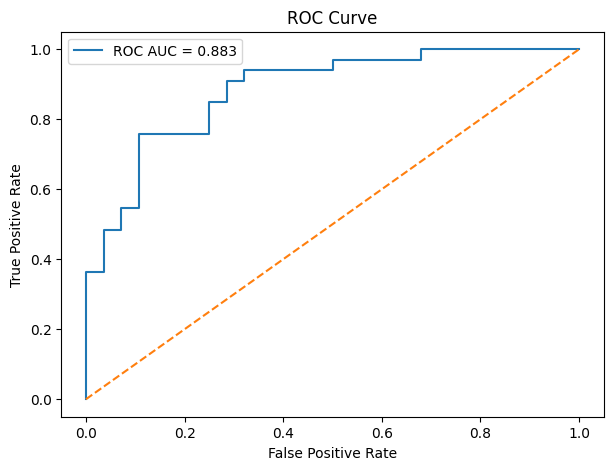

In [61]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

16) Plot Precision-Recall curve

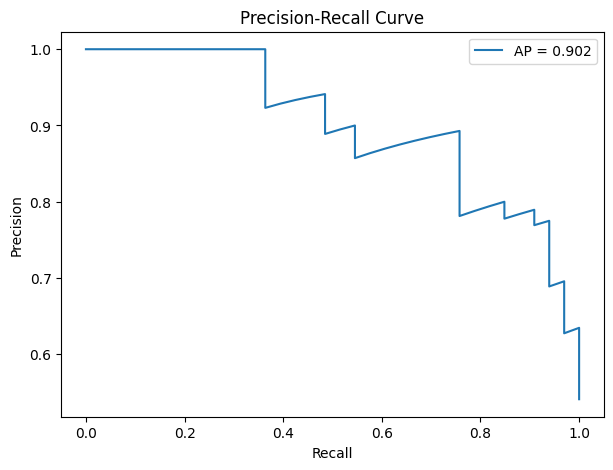

In [62]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {average_precision_score(y_test, y_proba):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

17) Plot calibration curve

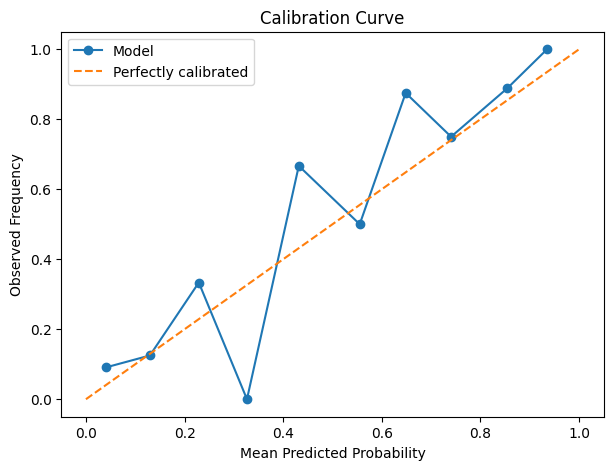

In [63]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

18) Find a better decision threshold

In [64]:
thresholds = np.arange(0.20, 0.81, 0.05)

results = []
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "accuracy": accuracy_score(y_test, preds)
    })

threshold_df = pd.DataFrame(results)
threshold_df.sort_values(by="f1", ascending=False)

,threshold,precision,recall,f1,accuracy
1,0.25,0.775000,0.939394,0.849315,0.819672
4,0.40,0.789474,0.909091,0.845070,0.819672
3,0.35,0.789474,0.909091,0.845070,0.819672
2,0.30,0.769231,0.909091,0.833333,0.803279
0,0.20,0.738095,0.939394,0.826667,0.786885
6,0.50,0.800000,0.848485,0.823529,0.803279
5,0.45,0.777778,0.848485,0.811594,0.786885
8,0.60,0.888889,0.727273,0.800000,0.803279
7,0.55,0.806452,0.757576,0.781250,0.770492
9,0.65,0.863636,0.575758,0.690909,0.721311


19) Save the final model

In [65]:
artifacts = {
    "preprocessor": preprocessor,
    "chosen_name": chosen_name,
    "model": chosen_model,
    "calibrated_model": calibrated_model,
    "target_column": TARGET,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}

joblib.dump(artifacts, "heart_disease_model_artifacts.joblib")
print("Saved successfully.")

Saved successfully.


20) Load model later and predict new patients

In [66]:
artifacts = joblib.load("heart_disease_model_artifacts.joblib")

preprocessor = artifacts["preprocessor"]
chosen_name = artifacts["chosen_name"]
calibrated_model = artifacts["calibrated_model"]

In [67]:
# Example: one new patient row
new_data = pd.DataFrame([{
    "age": 54,
    "sex": 1,
    "cp": 0,
    "trestbps": 125,
    "chol": 212,
    "fbs": 0,
    "restecg": 1,
    "thalach": 168,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 2,
    "ca": 2,
    "thal": 3
}])

In [68]:
if chosen_name == "HistGradientBoosting":
    new_processed = preprocessor.transform(new_data)
    risk = calibrated_model.predict_proba(new_processed)[:, 1][0]
else:
    risk = calibrated_model.predict_proba(new_data)[:, 1][0]

print(f"Predicted likelihood of heart disease: {risk:.2%}")

Predicted likelihood of heart disease: 34.11%
